✅ 2D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\37_corr_2d.png
✅ 3D Asset kaydedildi: C:\Users\ozhan\Desktop\The-Mathematical-Lab-Bench-main\The-Mathematical-Lab-Bench-main\assets\37_corr_3d.png


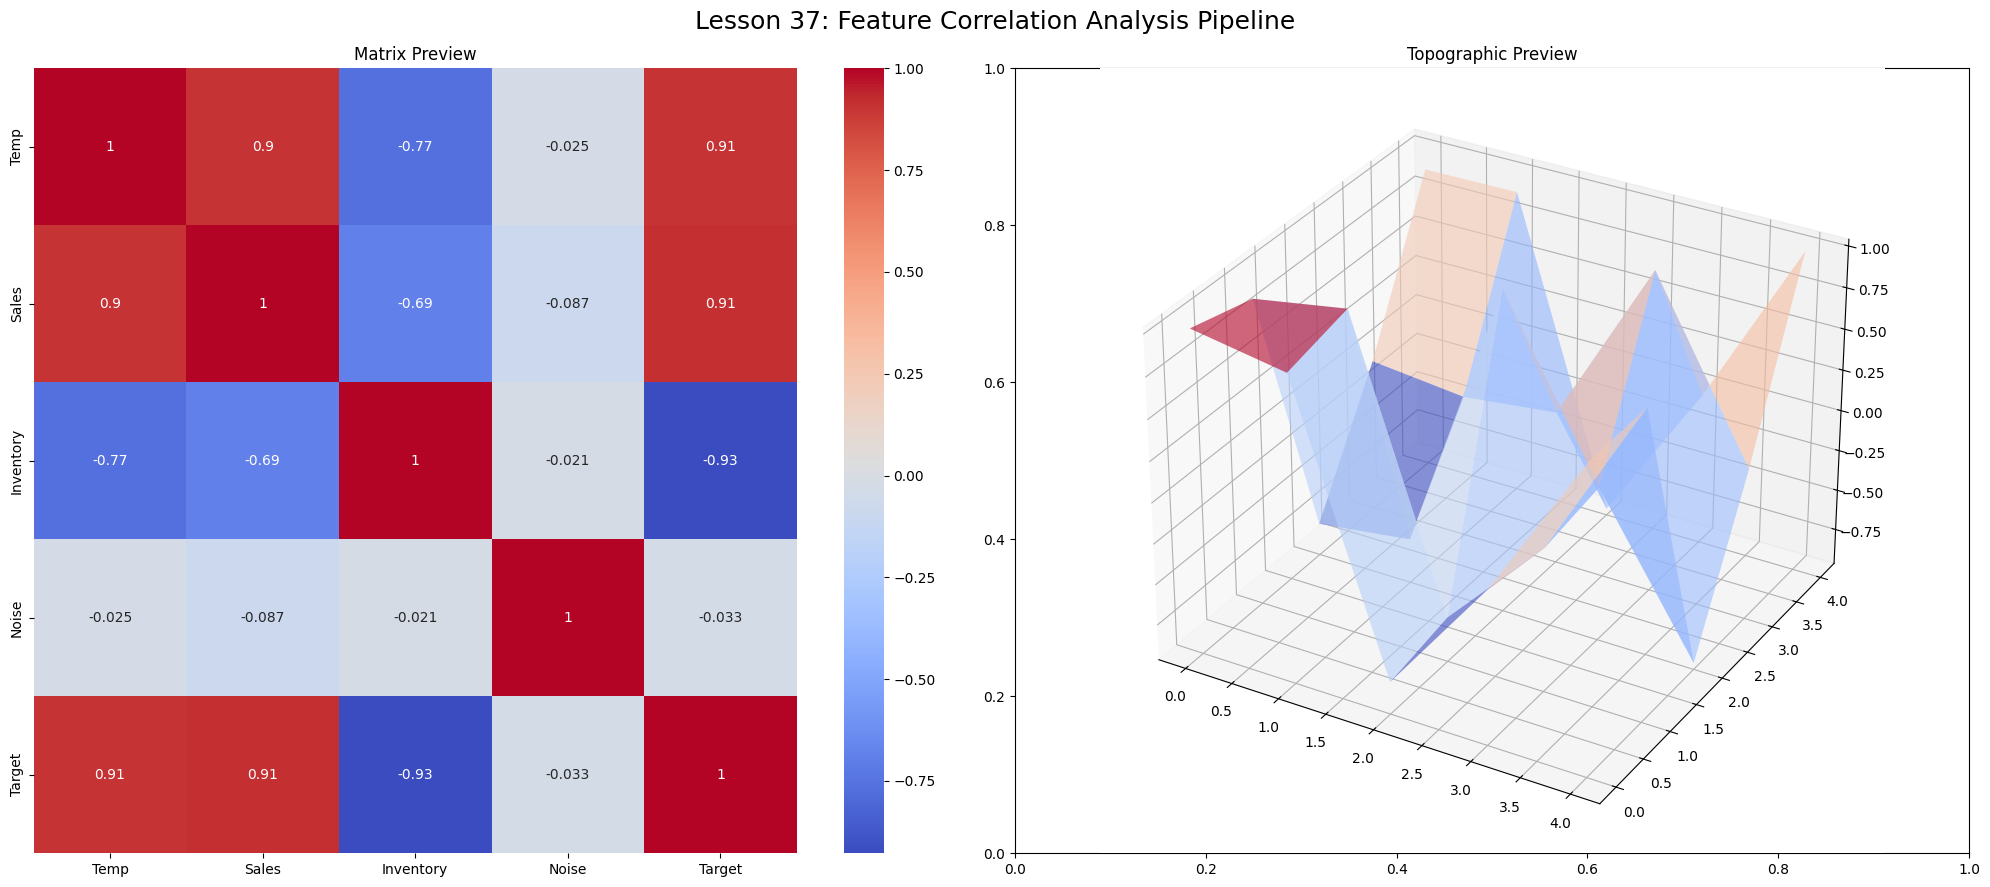

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import os

def run_correlation_master():
    # --- YOL AYARI (Ph.D. Disiplini) ---
    asset_path = r'../../../assets'
    if not os.path.exists(asset_path):
        os.makedirs(asset_path)

    # 1. Sentetik Veri Üretimi (Birbiriyle ilişkili 5 özellik)
    np.random.seed(101)
    n_samples = 100
    x1 = np.random.randn(n_samples)
    x2 = x1 + np.random.normal(0, 0.5, n_samples)  # x1 ile güçlü pozitif
    x3 = -x1 + np.random.normal(0, 0.8, n_samples) # x1 ile negatif
    x4 = np.random.randn(n_samples)                # Bağımsız
    x5 = 0.5 * x2 - 0.5 * x3                       # Karmaşık ilişki
    
    df = pd.DataFrame({'Temp': x1, 'Sales': x2, 'Inventory': x3, 'Noise': x4, 'Target': x5})
    corr_matrix = df.corr()

    # --- 📸 ASSET 1: SADECE 2D GRAFİK (37_corr_2d.png) ---
    fig2d = plt.figure(figsize=(10, 8))
    ax2d = fig2d.add_subplot(111)
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", ax=ax2d,
                linewidths=1, linecolor='white')
    ax2d.set_title("2D Pearson Correlation Heatmap", fontsize=14)
    
    plt.savefig(os.path.join(asset_path, '37_corr_2d.png'), dpi=300)
    print(f"✅ 2D Asset kaydedildi: {asset_path}\\37_corr_2d.png")
    plt.close(fig2d)

    # --- 📸 ASSET 2: SADECE 3D GRAFİK (37_corr_3d.png) ---
    fig3d = plt.figure(figsize=(10, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    
    # 3D Yüzey Hazırlığı
    x_indices = np.arange(len(corr_matrix.columns))
    y_indices = np.arange(len(corr_matrix.index))
    X, Y = np.meshgrid(x_indices, y_indices)
    Z = corr_matrix.values

    # Yüzeyi ve noktaları çiz
    surf = ax3d.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.8, edgecolor='none')
    ax3d.scatter(X, Y, Z, color='black', s=50) # Her korelasyon hücresi için nokta
    
    # Etiketler
    ax3d.set_xticks(x_indices)
    ax3d.set_xticklabels(corr_matrix.columns)
    ax3d.set_yticks(y_indices)
    ax3d.set_yticklabels(corr_matrix.index)
    
    ax3d.set_title("3D Correlation Landscape", fontsize=14)
    ax3d.set_zlabel('Correlation ($r$)')
    ax3d.set_zlim(-1, 1)
    
    plt.savefig(os.path.join(asset_path, '37_corr_3d.png'), dpi=300)
    print(f"✅ 3D Asset kaydedildi: {asset_path}\\37_corr_3d.png")
    plt.close(fig3d)

    # --- 🖥️ DASHBOARD (Preview) ---
    fig_dash, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=ax1)
    ax1.set_title("Matrix Preview")
    
    ax2 = fig_dash.add_subplot(122, projection='3d')
    ax2.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.6)
    ax2.set_title("Topographic Preview")
    
    plt.suptitle("Lesson 37: Feature Correlation Analysis Pipeline", fontsize=18)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_correlation_master()